# 01. Разведочный анализ (EDA)

Цель: понять структуру датасета `digital-advertising-campaign-performance-dataset`, распределение таргета `profit`, выявить пропуски, дубликаты, выбросы, зависимости и сформулировать стратегию препроцессинга и сплита.


In [1]:
import sys, os
from pathlib import Path
ROOT = Path().resolve().parent if Path().resolve().name == 'notebooks' else Path().resolve()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (
    TARGET, ID_COLS, DATE_COL, LEAKAGE_COLS,
    NUM_COLS, CAT_LOW_COLS, BOOL_COLS, REPORT_IMAGES_DIR,
)
from src.data_loader import load_raw
from src.utils import set_seed

set_seed()
sns.set_theme(style='whitegrid')
REPORT_IMAGES_DIR.mkdir(parents=True, exist_ok=True)


## Загрузка и первый взгляд

In [2]:
df = load_raw()
print(f'rows = {len(df):,}, cols = {df.shape[1]}')
df.head(3)


rows = 10,000, cols = 41


,campaign_id,campaign_objective,platform,ad_placement,device_type,operating_system,creative_format,creative_size,ad_copy_length,has_call_to_action,...,avg_session_duration_seconds,pages_per_session,industry_vertical,budget_tier,CTR,CPC,conversion_rate,CPA,ROAS,profit
0,CAMP_00001,Lead Generation,Facebook,Search,Mobile,Android,Text,728x90,Short,False,...,70,2.00,E-commerce,High,0.606,2.23,0.498,448.23,0.32,-606.79
1,CAMP_00002,Engagement,Facebook,Feed,Mobile,iOS,Image,320x50,Long,True,...,105,2.74,Finance,Medium,0.932,2.48,1.071,231.63,1.49,570.04
2,CAMP_00003,Conversions,Google Ads,Feed,Tablet,iOS,Video,1920x1080,Short,False,...,149,3.97,Healthcare,Low,1.033,3.88,5.357,72.43,6.68,2468.70


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   campaign_id                   10000 non-null  str           
 1   campaign_objective            10000 non-null  str           
 2   platform                      10000 non-null  str           
 3   ad_placement                  10000 non-null  str           
 4   device_type                   10000 non-null  str           
 5   operating_system              10000 non-null  str           
 6   creative_format               10000 non-null  str           
 7   creative_size                 10000 non-null  str           
 8   ad_copy_length                10000 non-null  str           
 9   has_call_to_action            10000 non-null  bool          
 10  creative_emotion              10000 non-null  str           
 11  creative_age_days             10000 non-

In [4]:
df.describe(include='all').T.head(40)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
campaign_id,10000,10000,CAMP_00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
campaign_objective,10000,5,Lead Generation,3563,NaN,NaN,NaN,NaN,NaN,NaN,NaN
platform,10000,6,Google Ads,2933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ad_placement,10000,6,Feed,3491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_type,10000,3,Mobile,5430,NaN,NaN,NaN,NaN,NaN,NaN,NaN
operating_system,10000,5,Android,2984,NaN,NaN,NaN,NaN,NaN,NaN,NaN
creative_format,10000,6,Image,3522,NaN,NaN,NaN,NaN,NaN,NaN,NaN
creative_size,10000,6,1920x1080,2497,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ad_copy_length,10000,3,Medium,4052,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_call_to_action,10000,2,True,6939,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Пропуски

Фиксируем долю NaN по колонкам. Даже если пропусков нет сейчас, добавим в препроцессинг импутеры (медиана / `missing`) — это защитит пайплайн при повторных запусках и новых данных.

In [5]:
na = df.isna().mean().sort_values(ascending=False)
na = na[na > 0]
if len(na) == 0:
    print('Пропусков нет.')
else:
    na.to_frame('missing_ratio').head(30)


Пропусков нет.


## Дубликаты

In [6]:
dupes = int(df.duplicated().sum())
print(f'Полных дубликатов: {dupes}')
if ID_COLS and ID_COLS[0] in df.columns:
    print(f"Дубликатов по {ID_COLS[0]}: {int(df.duplicated(subset=ID_COLS).sum())}")


Полных дубликатов: 0
Дубликатов по campaign_id: 0


## Таргет: распределение `profit`

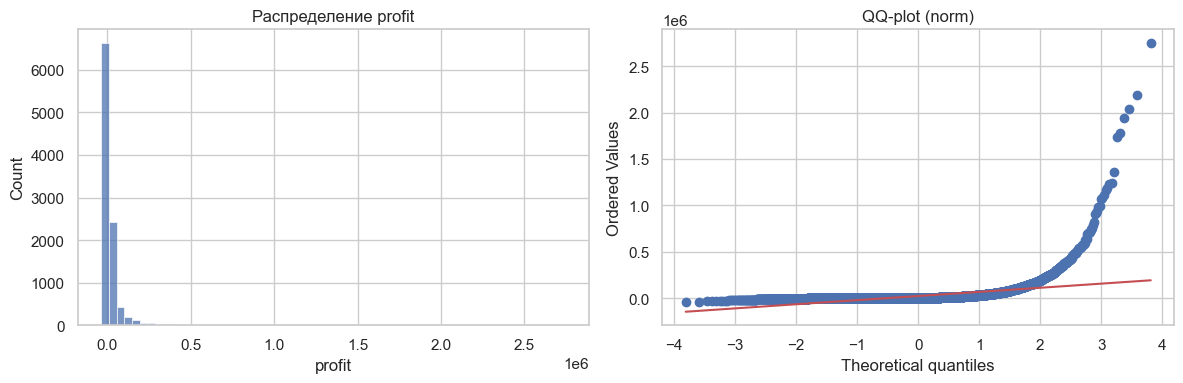

Доля отрицательного profit: 21.7%
count    1.000000e+04
mean     2.407020e+04
std      8.641610e+04
min     -3.693984e+04
25%      2.094800e+02
50%      3.302535e+03
75%      1.664188e+04
max      2.750398e+06
Name: profit, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[TARGET], bins=60, ax=axes[0])
axes[0].set_title('Распределение profit')

from scipy import stats
stats.probplot(df[TARGET], dist='norm', plot=axes[1])
axes[1].set_title('QQ-plot (norm)')
fig.tight_layout()
fig.savefig(REPORT_IMAGES_DIR / 'target_distribution.png', dpi=120)
plt.show()

neg_share = float((df[TARGET] < 0).mean())
print(f'Доля отрицательного profit: {neg_share:.1%}')
print(df[TARGET].describe())


Отрицательный `profit` встречается массово — это означает, что **логарифм таргета не применим** (log/RMSLE/MAPE не определены на неположительных значениях). Основная метрика — **RMSE**, дополнительные — **MAE** и **R²**.

## Утечки: почему нельзя использовать часть признаков

In [8]:
# profit == revenue - ad_spend (с точностью до округления). Доказываем.
reconstructed = (df['revenue'] - df['ad_spend']).round(2)
match = float((reconstructed - df[TARGET]).abs().le(1e-6).mean())
print(f'Доля строк, где round(revenue - ad_spend, 2) == profit: {match:.2%}')
corr_lk = df[LEAKAGE_COLS + [TARGET]].corr()[TARGET].sort_values(ascending=False)
corr_lk


Доля строк, где round(revenue - ad_spend, 2) == profit: 100.00%


profit        1.000000
revenue       0.997432
ROAS          0.432579
ad_spend      0.381534
CPC          -0.052586
actual_cpc   -0.052586
CPA          -0.144140
Name: profit, dtype: float64

Таким образом, колонки `revenue`, `ad_spend`, `ROAS`, `CPA`, `CPC`, `actual_cpc` прямо выражают таргет и будут удалены из фич (см. `src/config.LEAKAGE_COLS` и `src/preprocessing._drop_leakage`).

## Выбросы по ключевым числовым фичам

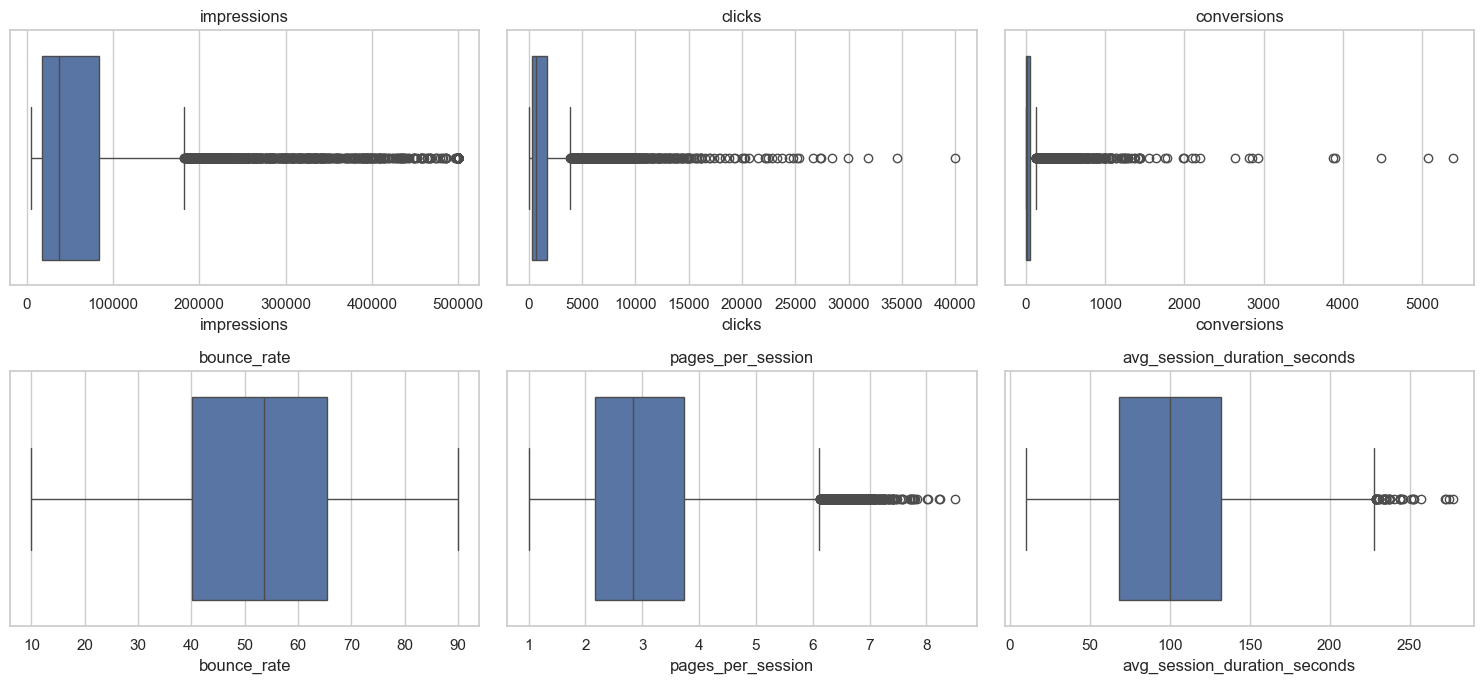

In [9]:
check_cols = [c for c in ['impressions', 'clicks', 'conversions', 'bounce_rate', 
                          'pages_per_session', 'avg_session_duration_seconds'] if c in df.columns]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.ravel(), check_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
fig.tight_layout()
fig.savefig(REPORT_IMAGES_DIR / 'numeric_outliers.png', dpi=120)
plt.show()


## Корреляции фичей с `profit` (без leakage-колонок)

In [10]:
feat_df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns])
num_df = feat_df.select_dtypes(include='number')
corr = num_df.corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
corr.to_frame('corr_with_profit').head(15)


,corr_with_profit
conversions,0.830402
clicks,0.510905
conversion_rate,0.402843
impressions,0.290740
CTR,0.266422
bounce_rate,-0.221660
pages_per_session,0.179107
avg_session_duration_seconds,0.141331
quality_score,0.106491
creative_age_days,-0.052393


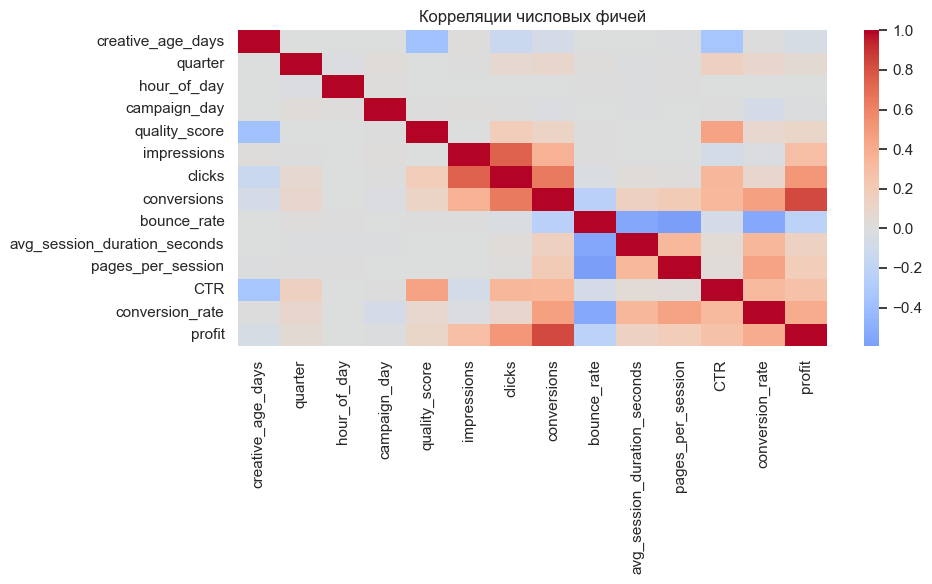

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(num_df.corr(), annot=False, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Корреляции числовых фичей')
fig.tight_layout()
fig.savefig(REPORT_IMAGES_DIR / 'corr_heatmap.png', dpi=120)
plt.show()


## Категории vs profit

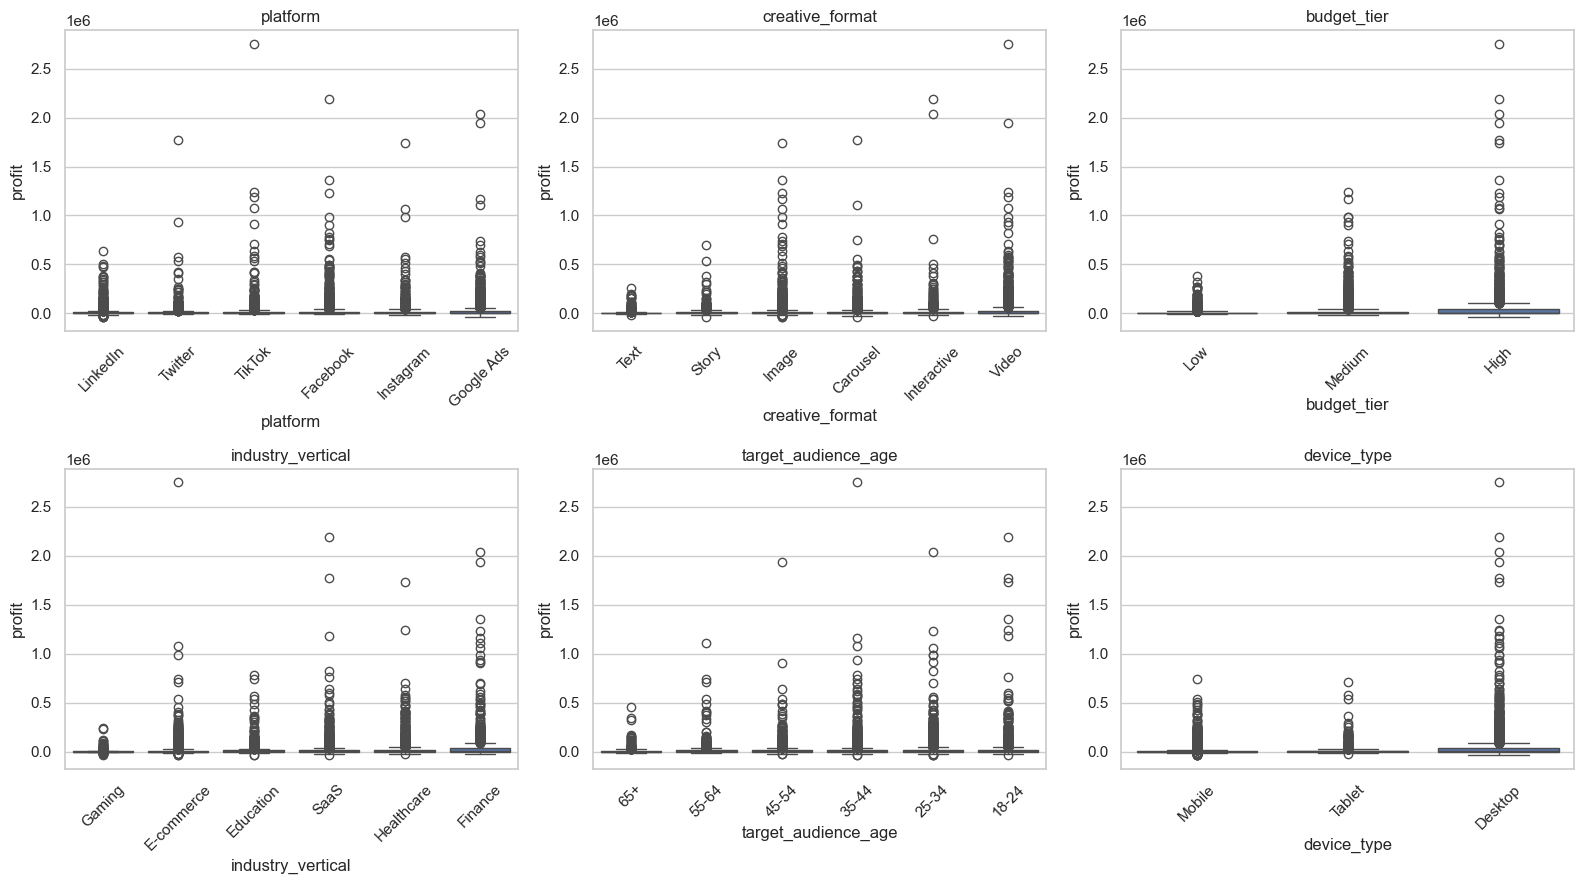

In [12]:
cat_to_plot = [c for c in ['platform', 'creative_format', 'budget_tier',
                           'industry_vertical', 'target_audience_age', 'device_type']
               if c in df.columns]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), cat_to_plot):
    order = df.groupby(col)[TARGET].median().sort_values().index
    sns.boxplot(x=col, y=TARGET, data=df, order=order, ax=ax)
    ax.tick_params(axis='x', rotation=45)
    ax.set_title(col)
fig.tight_layout()
fig.savefig(REPORT_IMAGES_DIR / 'profit_by_category.png', dpi=120)
plt.show()


## Временной аспект

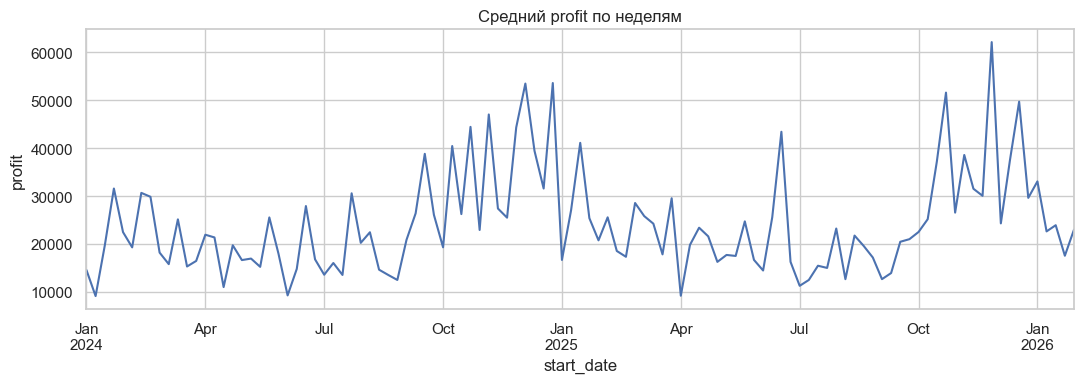

Диапазон дат: 2024-01-01 00:00:00 — 2026-01-30 00:00:00


In [13]:
if DATE_COL in df.columns:
    tmp = df[[DATE_COL, TARGET]].dropna().copy()
    tmp[DATE_COL] = pd.to_datetime(tmp[DATE_COL])
    monthly = tmp.set_index(DATE_COL).resample('W')[TARGET].mean()
    fig, ax = plt.subplots(figsize=(11, 4))
    monthly.plot(ax=ax)
    ax.set_title('Средний profit по неделям')
    ax.set_ylabel('profit')
    fig.tight_layout()
    fig.savefig(REPORT_IMAGES_DIR / 'profit_over_time.png', dpi=120)
    plt.show()
    print(f"Диапазон дат: {tmp[DATE_COL].min()} — {tmp[DATE_COL].max()}")


## Выводы EDA

- **Объём**: 10 000 строк, 41 колонка (требования CP1 по объёму выполнены).
- **Таргет**: `profit` распределён с тяжёлыми хвостами и содержит отрицательные значения, поэтому log-трансформ таргета неприменим. Основная метрика — RMSE.
- **Leakage**: `revenue`, `ad_spend`, `ROAS`, `CPA`, `CPC`, `actual_cpc` — прямые компоненты таргета; они удалены из фичей в пайплайне.
- **Пропусков** практически нет, дубликатов нет; `campaign_id` уникален.
- **Выбросы** умеренные — оставляем как есть, используя устойчивые модели и StandardScaler с медианной импутацией.
- **Сплит**: есть `start_date`, поэтому используем **time-based split** (см. `src/preprocessing.time_or_random_split`), чтобы не учить модель на будущем.
